In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.metrics import accuracy_score,classification_report
from sklearn.feature_selection import f_classif,chi2
from sklearn.preprocessing import OrdinalEncoder,StandardScaler,LabelEncoder
from sklearn.ensemble import RandomForestClassifier,BaggingClassifier,AdaBoostClassifier

In [2]:
xlsx = pd.ExcelFile("glass.xlsx")
print(xlsx.sheet_names)

['Description', 'glass']


In [3]:
Data = pd.read_excel(xlsx,sheet_name="glass")
Data.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


In [4]:
Data.shape

(214, 10)

In [5]:
Data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 16.8 KB


In [6]:
Data.describe()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
count,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000
mean,1.518365,13.407850,2.684533,1.444907,72.650935,0.497056,8.956963,0.175047,0.057009,2.780374
std,0.003037,0.816604,1.442408,0.499270,0.774546,0.652192,1.423153,0.497219,0.097439,2.103739
min,1.511150,10.730000,0.000000,0.290000,69.810000,0.000000,5.430000,0.000000,0.000000,1.000000
25%,1.516522,12.907500,2.115000,1.190000,72.280000,0.122500,8.240000,0.000000,0.000000,1.000000
50%,1.517680,13.300000,3.480000,1.360000,72.790000,0.555000,8.600000,0.000000,0.000000,2.000000
75%,1.519157,13.825000,3.600000,1.630000,73.087500,0.610000,9.172500,0.000000,0.100000,3.000000
max,1.533930,17.380000,4.490000,3.500000,75.410000,6.210000,16.190000,3.150000,0.510000,7.000000


### EDA Exploratory data Analysis

In [7]:
Data.isnull().sum()

RI      0
Na      0
Mg      0
Al      0
Si      0
K       0
Ca      0
Ba      0
Fe      0
Type    0
dtype: int64

In [8]:
Data.duplicated().sum()

np.int64(1)

In [9]:
Data.drop_duplicates(inplace=True,ignore_index=True)

In [10]:
Data.duplicated().sum()

np.int64(0)

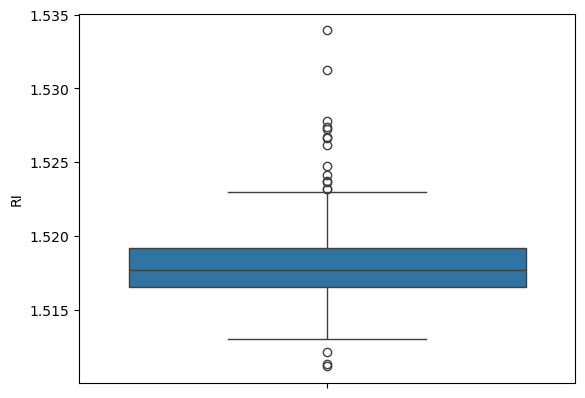

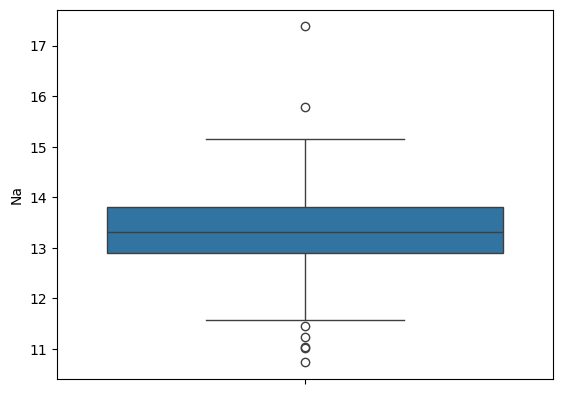

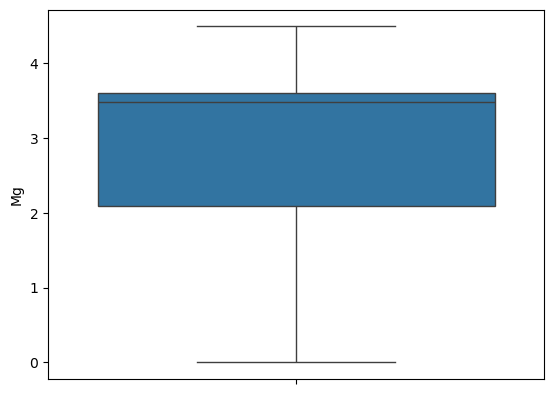

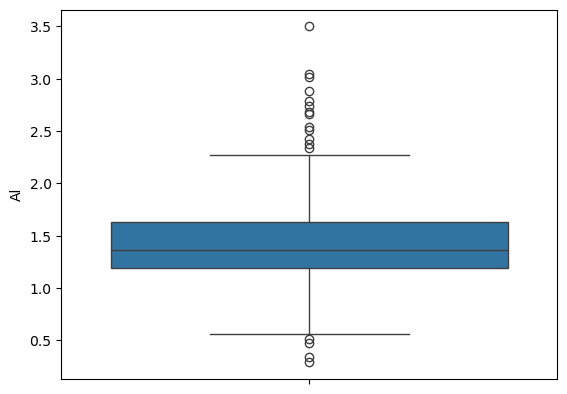

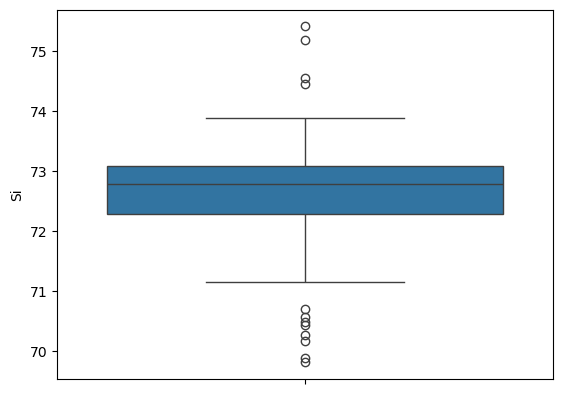

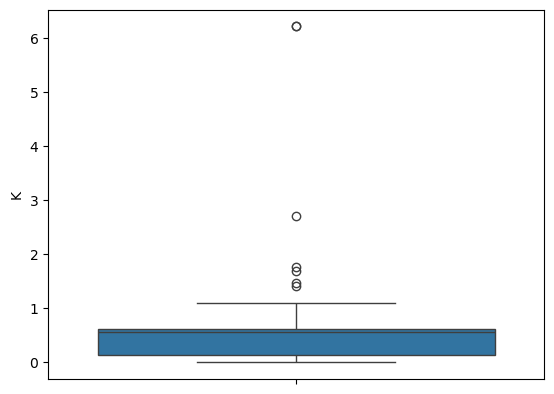

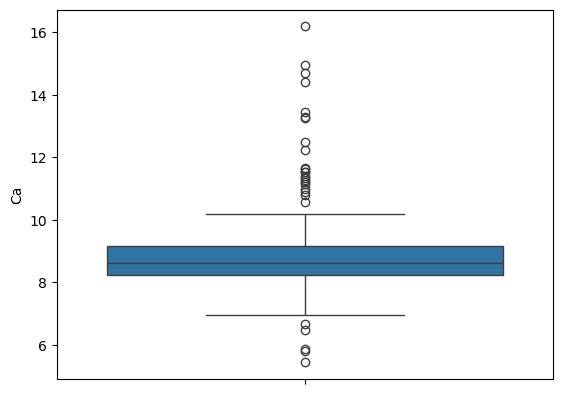

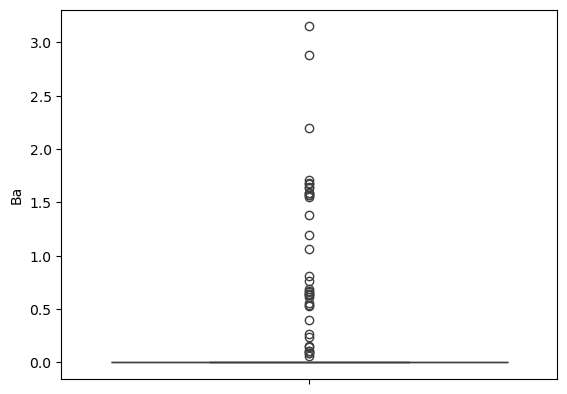

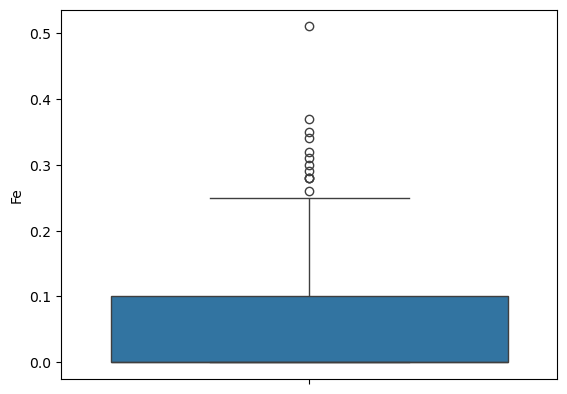

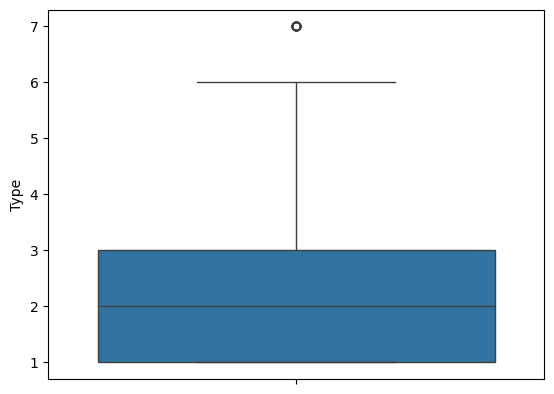

In [11]:
for col in Data.columns:
    sns.boxplot(data=Data,y=col)
    plt.show()

In [12]:
def outliers_capping(df,column):
    Q1=df[column].quantile(0.25)
    Q3=df[column].quantile(0.75)
    IQR=Q3-Q1
    lower_extreme=Q1-1.5*IQR
    upperr_extreme=Q3+1.5*IQR
    df[column]=df[column].apply(lambda x: lower_extreme if x<lower_extreme else upperr_extreme if x>upperr_extreme else x)
for col in Data.select_dtypes(include=['int','float']).columns:
    outliers_capping(Data,col)

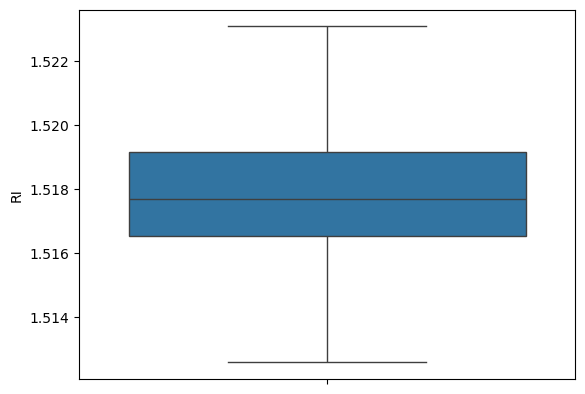

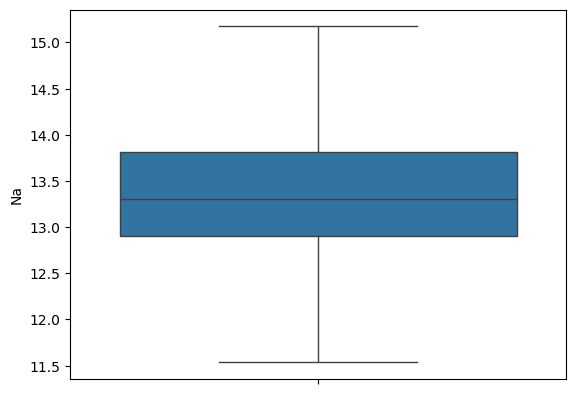

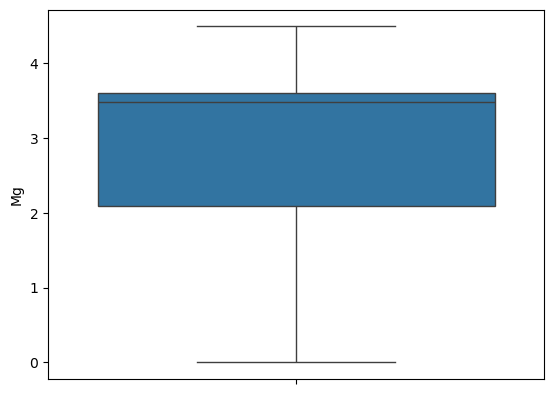

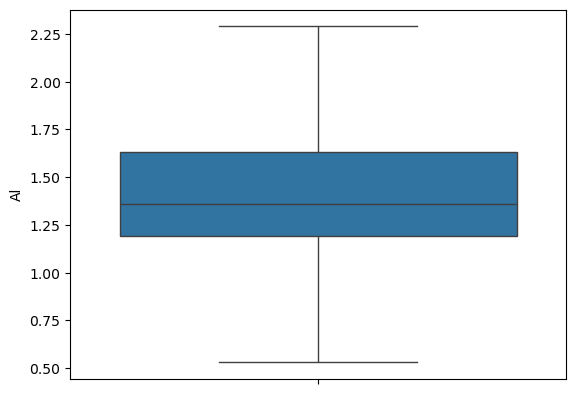

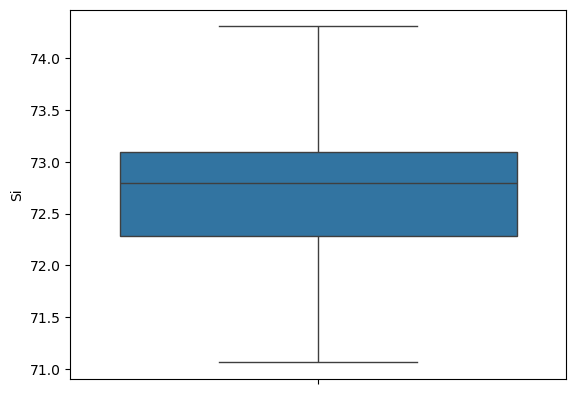

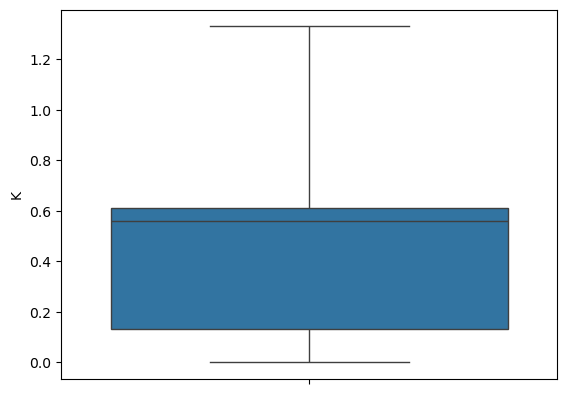

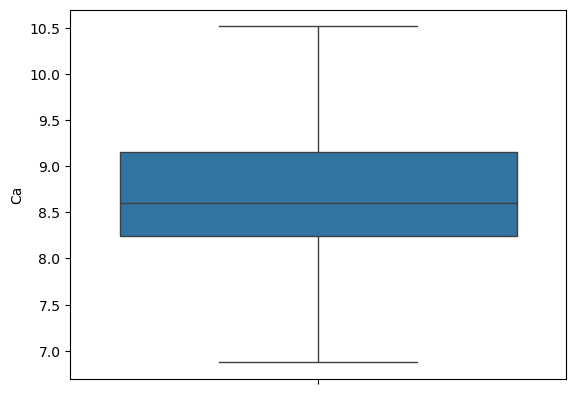

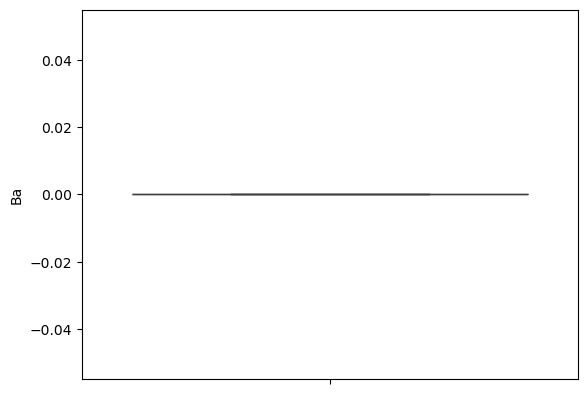

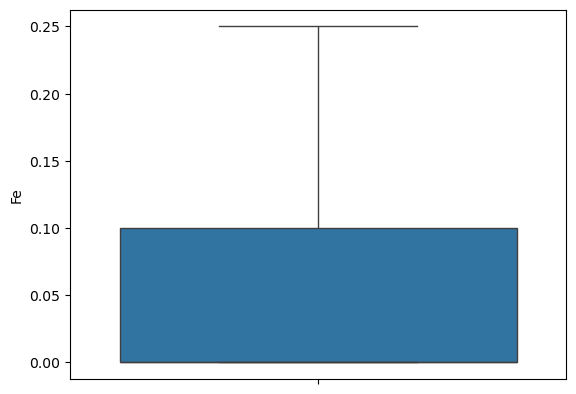

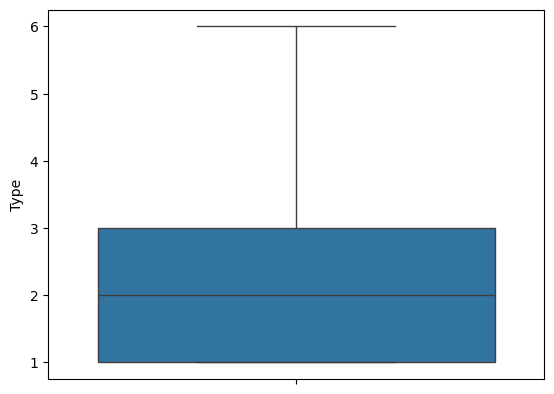

In [13]:
for col in Data.columns:
    sns.boxplot(data=Data,y=col)
    plt.show()

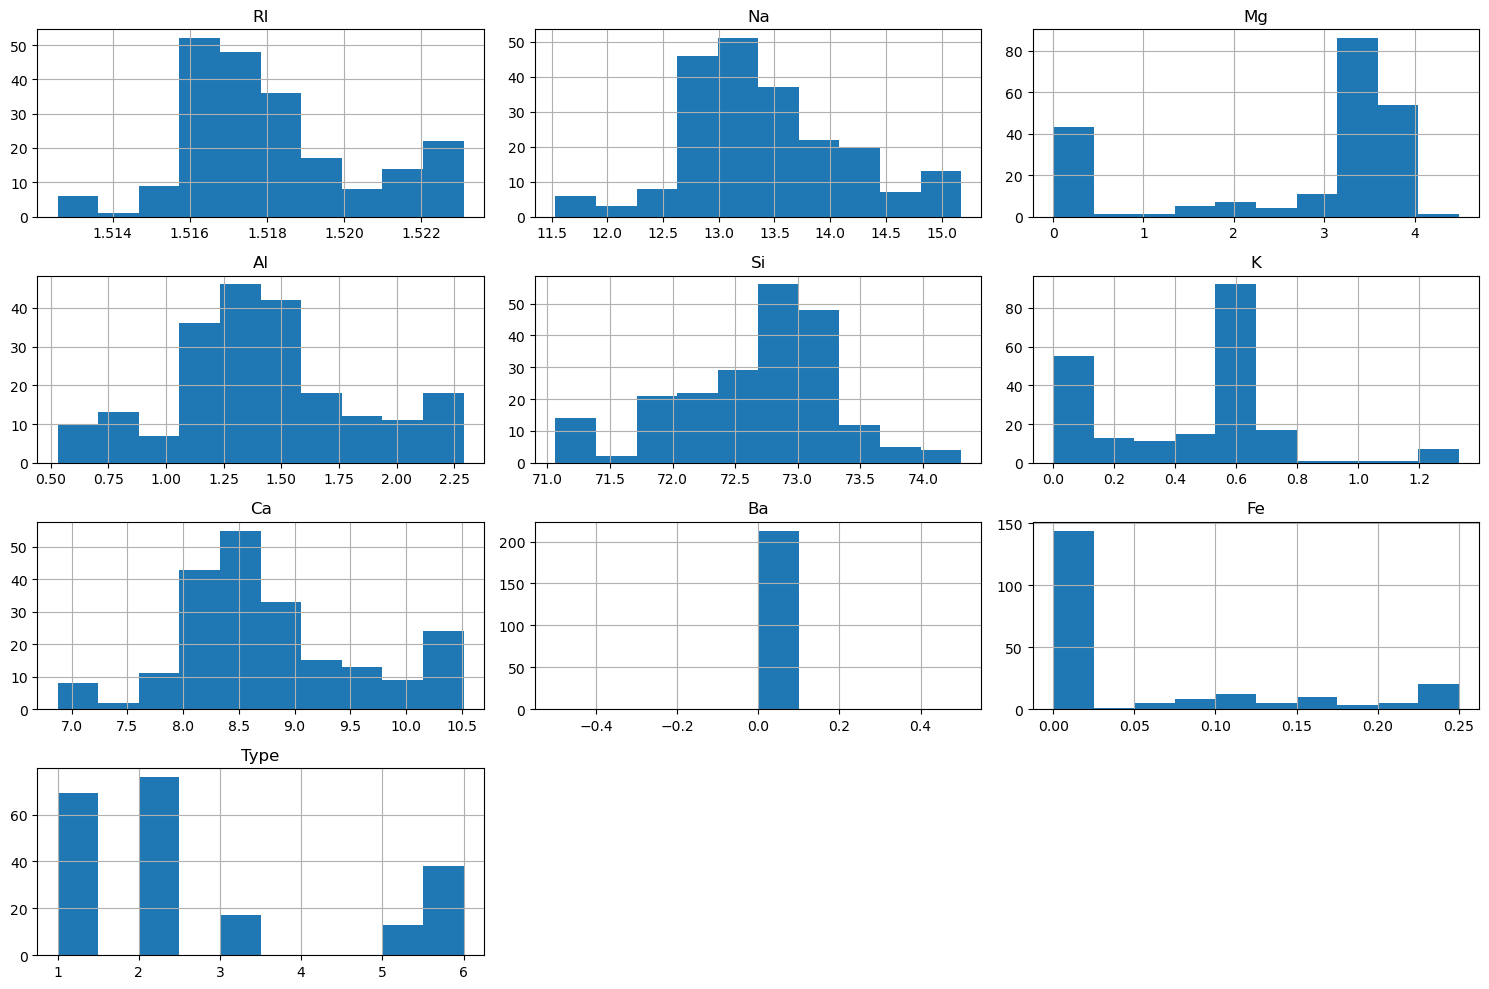

In [14]:
Data.hist(figsize=(15,10))
plt.title('Histogram')
plt.tight_layout()
plt.show()

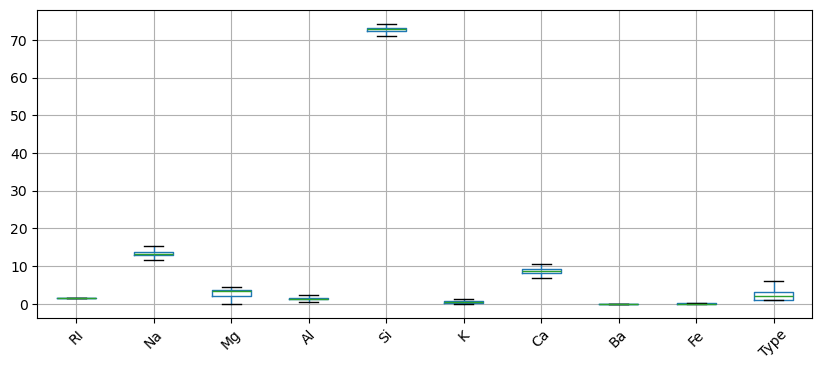

In [15]:
plt.figure(figsize=(10,4))
Data.boxplot()
plt.xticks(rotation=45)
plt.show()

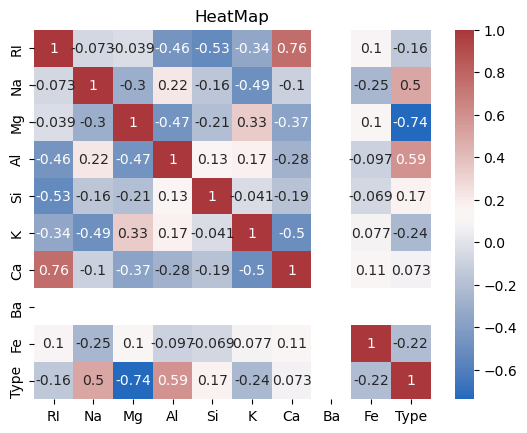

In [16]:
sns.heatmap(Data.corr(numeric_only=True),annot=True,cmap='vlag')
plt.title("HeatMap")
plt.show()

In [17]:
target = Data[['Type']]
features = Data.drop(columns=['Type'])
features.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0


In [18]:
std_sca = StandardScaler()
x_scaled = std_sca.fit_transform(features)

In [19]:
from imblearn.over_sampling import SMOTE
smote=SMOTE(random_state=42)
X_resampled,y_resampled=smote.fit_resample(x_scaled,target)

In [20]:
x_train,x_test,y_train,y_test = train_test_split(X_resampled,y_resampled,train_size=0.8,random_state=42)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(304, 9)
(76, 9)
(304, 1)
(76, 1)


In [21]:
rf = RandomForestClassifier(n_estimators=200,random_state=42,class_weight='balanced')
rf.fit(x_train,y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

In [22]:
y_pred = rf.predict(x_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9078947368421053
              precision    recall  f1-score   support

         1.0       0.94      0.84      0.89        19
         2.0       0.80      0.75      0.77        16
         3.0       0.94      1.00      0.97        17
         5.0       0.93      1.00      0.96        13
         6.0       0.92      1.00      0.96        11

    accuracy                           0.91        76
   macro avg       0.91      0.92      0.91        76
weighted avg       0.91      0.91      0.91        76



In [23]:
#Accuracy → Overall correctness
#Precision → Correct positive predictions
#Recall → Ability to capture actual positives
#F1-score → Balance between precision & recall

### Bagging and Boosting Methods :

In [24]:
bagging = BaggingClassifier(estimator=DecisionTreeClassifier(),n_estimators=100,random_state=42)
bagging.fit(x_train,y_train)
y_pred_bag = bagging.predict(x_test)
print("Bagging Accuracy:",accuracy_score(y_test,y_pred_bag))

Bagging Accuracy: 0.9078947368421053


In [25]:
boost = AdaBoostClassifier(n_estimators=100,random_state=42)
boost.fit(x_train, y_train)
y_pred_boost = boost.predict(x_test)
print("Boosting Accuracy:", accuracy_score(y_test, y_pred_boost))

Boosting Accuracy: 0.5263157894736842


In [26]:
#Model :
#Random Forest : Best overall, robust to noise
#Bagging      :    Reduces variance
#Boosting     :  Improves weak learners

In [27]:
#Bagging : 

#Trains multiple independent models

#Uses bootstrap sampling

#Reduces variance

#Example: Random Forest

In [28]:
#Boosting :

#Trains models sequentially

#Focuses on previous errors

#Reduces bias

#Example: AdaBoost, Gradient Boosting

In [29]:
#Handling Imbalanced Data :

#Techniques:

#SMOTE – Synthetic data generation

#Class Weighting – Penalize minority misclassification

#Resampling – Over / Under sampling

#Evaluation Metrics – Use F1, Recall instead of Accuracy

In [30]:
#Conclusion :

#Glass dataset is multiclass and imbalanced

#Random Forest performs best

#SMOTE improves minority class recall